# Exercise 1: Home Value Estimation — California Housing

## Table of Contents

- [0. Context](#toc-context)
- [1. Load the data and split](#toc-1)
- [2. Integrity check before fitting](#toc-2)
- [3. Baseline models](#toc-3)
  - [(a) Predict the mean](#toc-3a)
  - [(b) Plain linear regression on all raw features](#toc-3b)
- [4. Error Analysis](#toc-4)
  - [(a) Comparing the two baselines](#toc-4a)
  - [(b) Target censoring](#toc-4b)
  - [(c) Leverage point from AveRooms/AveBedrms](#toc-4c)
  - [(d) Fixing the censoring and leverage problems](#toc-4d)
- [5. Model Comparison](#toc-5)
  - [(a) Choosing a metric](#toc-5a)
  - [(b) Underfitting assessment](#toc-5b)
  - [(c) Overfitting assessment](#toc-5c)
  - [(d) Feature importance assessment](#toc-5d)
  - [(e) Multicollinearity assessment](#toc-5e)
- [6. Beyond Linear Models](#toc-6)
  - [(a) Why a decision tree](#toc-6a)
  - [(b) Fitting and tuning](#toc-6b)
  - [(c) Comparing to the linear baseline](#toc-6c)
  - [(d) Reducing variance with ensembles](#toc-6d)
- [7. Conclusion](#toc-7)
  - [(a) Summary](#toc-7a)
  - [(b) What worked, and why](#toc-7b)
  - [(c) Why we stop here](#toc-7c)
  - [(d) Possible extensions](#toc-7d)

<a id="toc-context"></a>

## 0. Context

You've joined a small analytics team building a home-value estimation tool for California. Leadership wants a first-pass model before committing more resources, plus an honest read on how much to trust it.

### Data handed over

Census block groups from the 1990 U.S. Census, built into scikit-learn (`fetch_california_housing`). No download needed. Feature selection has already been done by the team: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, and location were judged relevant to home valuation before this data reached you. You don't need to go hunting for which raw signals matter. Whether this set is sufficient, or has more than it needs, is fair to revisit once you've seen how a first model performs.

- **MedInc**: median income in the block group (tens of thousands of USD)
- **HouseAge**: median house age
- **AveRooms** / **AveBedrms**: average rooms / bedrooms per household
- **Population**: block group population
- **AveOccup**: average household occupancy
- **Latitude** / **Longitude**: location

**Target: MedHouseVal.** Median house value for the block group, in hundreds of thousands of USD.

### Objective

Produce a first model, and report how good it actually is, including anything about the data itself that could make predictions misleading if ignored. No metric has been decided yet; that's part of the job.

### Approach

The approach for this module: get a simple baseline up fast, and let evidence from its own errors decide what happens next.

- **Model zero**: fit the simplest model on every available feature, as-is (feature selection is already done). Let its residuals drive what comes next, not speculation.
- A quick integrity check first: dtypes, missing values, and each variable's distribution, to rule out anything that would make the fit untrustworthy.
- Feature engineering and model comparisons come later, if the evidence calls for them.

<a id="toc-1"></a>

## 1. Load the data and split

We split into train and test first, before any EDA: exploring the full
dataset would mean treating all of it as training data, leaving nothing
held out to check whether conclusions generalize.

In [1]:
from sklearn.datasets        import fetch_california_housing
from sklearn.model_selection import train_test_split
import pandas as pd

housing = fetch_california_housing(as_frame=True)
df = housing.frame

X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

# set aside the test set now; it stays untouched until final evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"train: {X_train.shape}, test: {X_test.shape}")

train: (16512, 8), test: (4128, 8)


<a id="toc-2"></a>

## 2. Integrity check before fitting

Integrity, not engineering: dtypes, missing values, and the distribution of every variable, target included. Looking for anything that would make a fit untrustworthy, not deciding transforms yet.

In [2]:
# training set only: never peek at X_test/y_test here
print(f"dtypes:\n{X_train.dtypes}")
print(f"\nmissing values (features): {int(X_train.isna().sum().sum())}")
print(f"missing values (target):   {int(y_train.isna().sum())}")
print(f"\nfeature summary:\n{X_train.describe()}")
print(f"\ntarget summary:\n{y_train.describe()}")

dtypes:
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
dtype: object

missing values (features): 0
missing values (target):   0

feature summary:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  16512.000000  16512.000000  16512.000000  16512.000000  16512.000000   
mean       3.880754     28.608285      5.435235      1.096685   1426.453004   
std        1.904294     12.602499      2.387375      0.433215   1137.056380   
min        0.499900      1.000000      0.888889      0.333333      3.000000   
25%        2.566700     18.000000      4.452055      1.006508    789.000000   
50%        3.545800     29.000000      5.235874      1.049286   1167.000000   
75%        4.773175     37.000000      6.061037      1.100348   1726.000000   
max       15.000100     52.000000    141.909091     25.636364  35682.000000   

           Av

No missing values, no dtype surprises. A few extremes already stand out:
`AveRooms` and `AveOccup`'s maximums are wildly out of line with their
medians, and the target caps out at exactly 5.00001, which looks like a
truncated maximum rather than a real one.

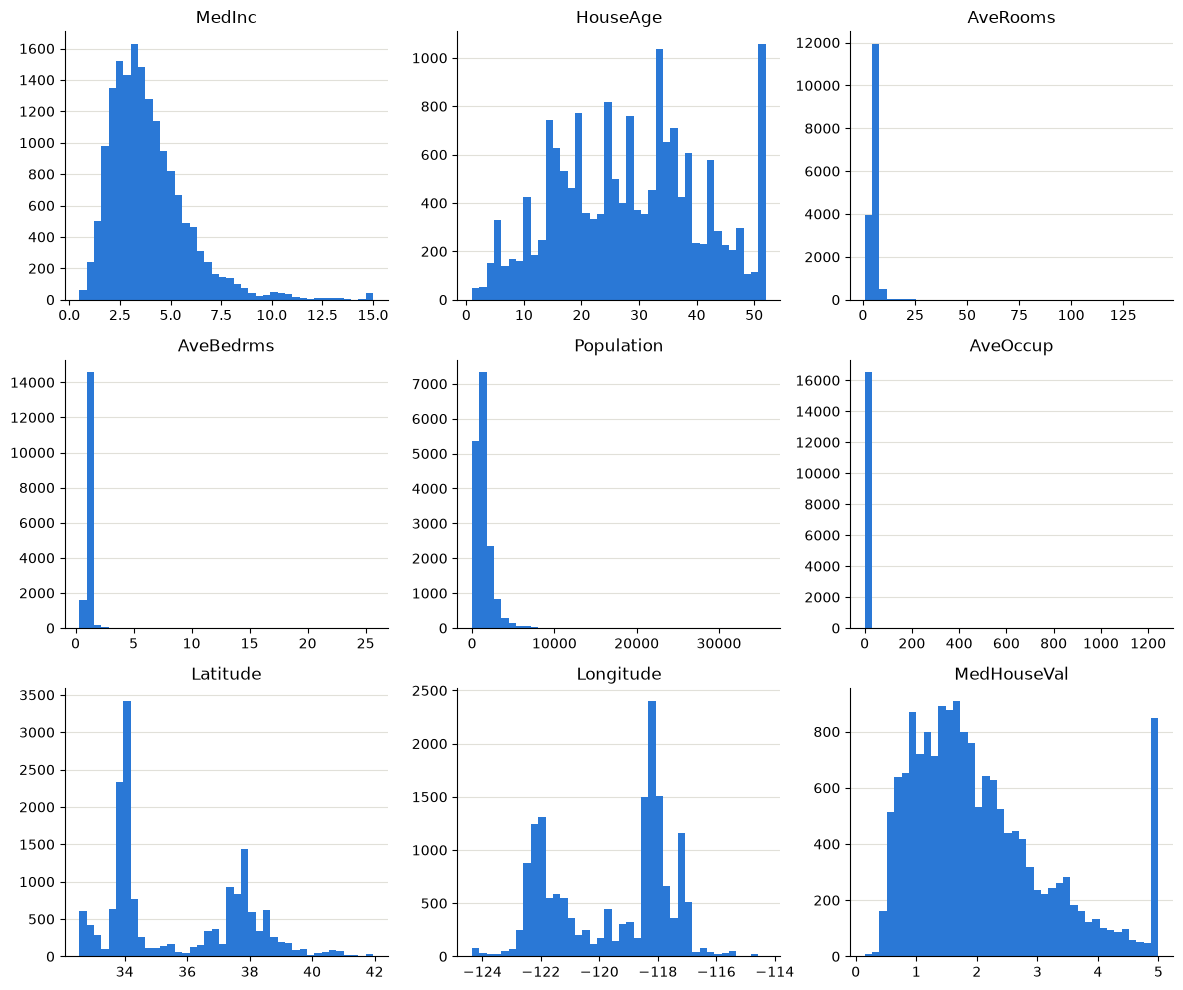

In [3]:
# quick visual pass: one histogram per feature, plus the target
import matplotlib.pyplot as plt

data = X_train.copy()
data["MedHouseVal"] = y_train

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for ax, col in zip(axes.flat, data.columns):
    ax.hist(data[col], bins=40, color="#2a78d6")
    ax.set_title(col)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)

plt.tight_layout()
plt.show()

The target's spike right at its maximum confirms a hard cutoff, not just a
high value. Several features (`AveRooms`, `AveBedrms`, `Population`,
`AveOccup`) are heavily right-skewed, with a handful of extreme outliers
driving their maximums. `HouseAge` shows that same spike-at-the-maximum
shape at its own cap of 52, hinting it may be capped the same way the
target is.

<a id="toc-3"></a>

## 3. Baseline models

A trivial floor and a first real model, to have something concrete to react to before judging anything else.

<a id="toc-3a"></a>

### (a) Predict the mean

The floor any real model has to clear: with no other information,
predicting the mean minimizes squared error, so beating it by a wide margin
is the first real test.

In [4]:
import numpy as np

# predict the training-set mean for every row in the test set
naive_pred = np.full(shape=y_test.shape, fill_value=y_train.mean())
naive_residuals = naive_pred - y_test.values  # predicted - actual, in $100k units

print("naive baseline residuals (predicted - actual):")
print(pd.Series(naive_residuals).describe())

naive baseline residuals (predicted - actual):
count    4128.000000
mean        0.016944
std         1.144870
min        -2.928063
25%        -0.558053
50%         0.285447
75%         0.879197
max         1.921957
dtype: float64


<a id="toc-3b"></a>

### (b) Plain linear regression on all raw features

No dropped columns, no transforms, no scaling (OLS doesn't need it: scaling only matters for regularized/gradient-descent-based fitting, which comes later). The point isn't a good score, it's a number to react to.

In [5]:
# fit on train, evaluate on test: the first legitimate use of X_test so far
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)
residuals = pred - y_test.values  # predicted - actual, in $100k units

print("baseline linear regression residuals (predicted - actual):")
print(pd.Series(residuals).describe())

baseline linear regression residuals (predicted - actual):
count    4128.000000
mean       -0.003479
std         0.745664
min        -4.148388
25%        -0.312442
50%         0.122439
75%         0.460935
max         9.875331
dtype: float64


<a id="toc-4"></a>

## 4. Error Analysis

Model zero's job isn't to be good, it's to produce errors worth learning
from. This section works through what those errors actually show, before
any decision gets made about what to do with them.

<a id="toc-4a"></a>

### (a) Comparing the two baselines

No metric committed to yet: just the raw residuals, side by side, for both baselines.

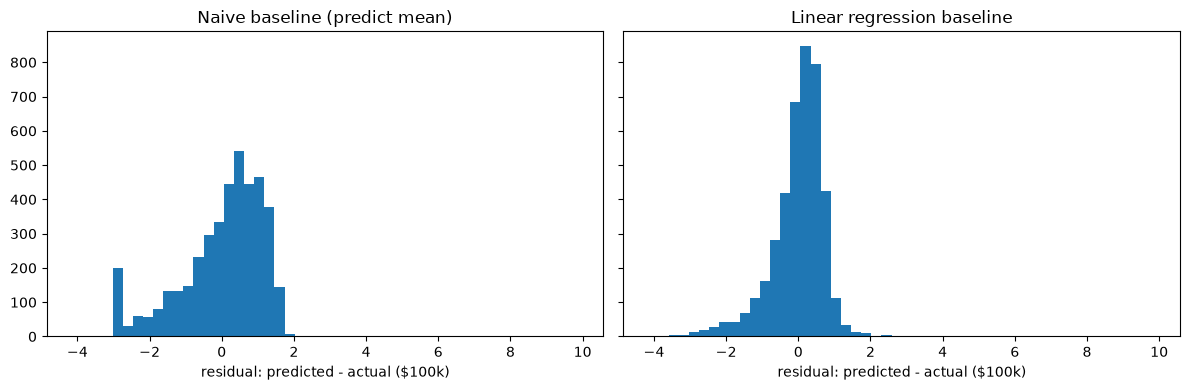

In [6]:
# compare both baselines' error distributions side by side; same bin range
# for both, so bar heights are actually comparable
shared_range = (min(naive_residuals.min(), residuals.min()),
                max(naive_residuals.max(), residuals.max()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

axes[0].hist(naive_residuals, bins=50, range=shared_range)
axes[0].set_title("Naive baseline (predict mean)")
axes[0].set_xlabel("residual: predicted - actual ($100k)")

axes[1].hist(residuals, bins=50, range=shared_range)
axes[1].set_title("Linear regression baseline")
axes[1].set_xlabel("residual: predicted - actual ($100k)")

plt.tight_layout()
plt.show()

Linear regression tightens the bulk of errors well: its spread (std 0.75) is
nearly half the naive baseline's (1.14). But its tail is far worse: a max
miss of +9.88 against the naive baseline's 1.92, and a min of -4.15 against
-2.93. Something specific is driving those extreme errors, not just general
noise, worth investigating before trusting any single average metric.

Two candidate explanations for the heavy tail: a hard cap on the target, and an extreme value in a feature that's itself a per-household ratio.

<a id="toc-4b"></a>

### (b) Target censoring

In [7]:
# (a) Target censoring: how much of the data sits exactly at the cap, and
# how biased is the model specifically on those points?
capped_mask = (y_test.values == y.max())
print(f"capped points in test set: {capped_mask.sum()} / {len(y_test)} ({capped_mask.mean():.1%})")
print(f"\nresiduals AT the cap:\n{pd.Series(residuals[capped_mask]).describe()}")
print(f"\nresiduals everywhere else:\n{pd.Series(residuals[~capped_mask]).describe()}")

capped points in test set: 179 / 4128 (4.3%)

residuals AT the cap:
count    179.000000
mean      -1.128152
std        1.379678
min       -4.148388
25%       -2.207698
50%       -1.190934
75%       -0.204870
max        2.260283
dtype: float64

residuals everywhere else:
count    3949.000000
mean        0.047500
std         0.659888
min        -3.632784
25%        -0.259281
50%         0.141655
75%         0.468142
max         9.875331
dtype: float64


Confirmed: 4.3% of the test set sits exactly at the cap, and residuals there
are biased sharply negative (mean -1.13, vs +0.05 everywhere else). The
model is predicting what it thinks the true value should be, often above
the cap, and gets penalized against a label that was truncated before
training ever saw it. A real, systematic effect, not noise.

<a id="toc-4c"></a>

### (c) Leverage point from AveRooms/AveBedrms

In [8]:
# (b) The single worst prediction: is it a leverage-point effect from AveRooms/AveBedrms?
worst_idx = residuals.argmax()
print(f"predicted: {pred[worst_idx]:.3f}   actual: {y_test.values[worst_idx]:.3f}")
print("\nfeature values for this row, and where they rank against the training set:")
row = X_test.iloc[worst_idx]
for col in X_test.columns:
    pctile = (X_train[col] < row[col]).mean() * 100
    print(f"  {col:12s} = {row[col]:10.3f}   ({pctile:5.1f}th percentile)")

predicted: 11.500   actual: 1.625

feature values for this row, and where they rank against the training set:
  MedInc       =      4.625   ( 72.5th percentile)
  HouseAge     =     34.000   ( 62.0th percentile)
  AveRooms     =    132.533   (100.0th percentile)
  AveBedrms    =     34.067   (100.0th percentile)
  Population   =     36.000   (  0.3th percentile)
  AveOccup     =      2.400   ( 23.3th percentile)
  Latitude     =     38.800   ( 94.3th percentile)
  Longitude    =   -120.080   ( 39.7th percentile)


Confirmed, and distinct from the censoring effect above: the worst
prediction (actual 1.625, predicted 11.5) comes from a row where `AveRooms`
and `AveBedrms` both sit at the 100th percentile (132.5 and 34.1). Both are
per-household ratios, and this block group's own numbers show why: working
backward from `Population`/`AveOccup` gives about 15 households, implying
roughly 1,988 total rooms and 511 total bedrooms between them. A tiny
denominator turns an unremarkable total into an extreme ratio.

Two different problems, two different fixes: target censoring is a
data-handling decision (how we treat those rows), not a modeling one; the
leverage point is a feature/model decision, since plain linear regression is
specifically vulnerable to a long-tailed ratio feature pulling its fit. Both
get addressed before the next model, not by picking a fancier algorithm
blindly.

That's one confirmed case. `Population` and `AveOccup` look just as skewed in the histograms, worth checking whether they cause the same kind of damage before deciding to transform them too.

In [9]:
# among non-capped test rows (censoring already explains those), how often is each feature at an extreme value for the worst-predicted rows?
n = 20
non_capped_idx = np.where(~capped_mask)[0]
worst_n_idx = non_capped_idx[np.argsort(np.abs(residuals[non_capped_idx]))[-n:]]
worst_rows = X_test.iloc[worst_n_idx]

print(f"Of the {n} worst non-capped predictions, how often each feature sits above the training set's 95th percentile:")
for col in X_test.columns:
    threshold = X_train[col].quantile(0.95)
    count = int((worst_rows[col] > threshold).sum())
    print(f"  {col:12s}: {count}/{n}")

Of the 20 worst non-capped predictions, how often each feature sits above the training set's 95th percentile:
  MedInc      : 2/20
  HouseAge    : 0/20
  AveRooms    : 3/20
  AveBedrms   : 4/20
  Population  : 0/20
  AveOccup    : 1/20
  Latitude    : 1/20
  Longitude   : 0/20


Evidence, not just skew: at this threshold, pure chance alone would produce
about 1 hit per feature across 20 rows (5% x 20). `AveBedrms` (4/20) and
`AveRooms` (3/20) clear that bar, consistent with the specific leverage
case already found above. `Population` (0/20) and `AveOccup` (1/20) don't,
despite being just as visually skewed; their extremes aren't actually
driving these errors. That argues for transforming `AveRooms`/`AveBedrms`
specifically, not applying a log transform to every peaked feature. Worth
noting too: most of these 20 worst predictions aren't explained by any
single feature being extreme at all, so some of the remaining error looks
more diffuse than one dominant, fixable cause.

<a id="toc-4d"></a>

### (d) Fixing the censoring and leverage problems

Two decisions, based on the evidence above, not on how the raw distributions looked:

- **Log-transform `AveRooms` and `AveBedrms`.** They're per-household ratios, and both the single worst prediction and the broader 20-row check point specifically at their extremes, not at `Population`/`AveOccup`, which only looked similarly skewed.
- **Exclude capped rows from training.** Their labels are known to be wrong, not just unusual, so training on them directly biases the fit. Capped test rows stay out of the primary evaluation number for the same reason, but get reported separately rather than silently dropped.

A formal censored-regression approach (a Tobit model) exists for exactly this kind of capped-target problem, and was considered. Deliberately not used here: it would mean estimating what's above the cap from a region of the data we have zero actual observations in, which is extrapolation past the edge of what we've ever seen, not interpolation within it. It's also a bigger statistical detour than this module is building toward, applied practice comparing standard supervised models, not specialized censored-outcome econometrics.

In [10]:
# apply both decisions: log-transform the two ratio features, and drop
# capped rows from training only (the test set stays exactly as-is)
X_train_eng = X_train.copy()
X_train_eng["AveRooms"]  = np.log(X_train_eng["AveRooms"])
X_train_eng["AveBedrms"] = np.log(X_train_eng["AveBedrms"])

X_test_eng = X_test.copy()
X_test_eng["AveRooms"]  = np.log(X_test_eng["AveRooms"])
X_test_eng["AveBedrms"] = np.log(X_test_eng["AveBedrms"])

train_capped_mask = (y_train.values == y.max())
X_train_eng = X_train_eng[~train_capped_mask]
y_train_eng = y_train[~train_capped_mask]

print(f"training rows kept: {len(y_train_eng)} / {len(y_train)} "
      f"({(~train_capped_mask).mean():.1%} non-capped)")

training rows kept: 15726 / 16512 (95.2% non-capped)


In [11]:
# refit with the engineering decisions applied
model_eng = LinearRegression()
model_eng.fit(X_train_eng, y_train_eng)

pred_eng = model_eng.predict(X_test_eng)
residuals_eng = pred_eng - y_test.values

print(f"engineered model, non-capped test rows (the honest comparison):\n{pd.Series(residuals_eng[~capped_mask]).describe()}")
print(f"\nengineered model, capped test rows (known limitation, reported not hidden):\n{pd.Series(residuals_eng[capped_mask]).describe()}")

engineered model, non-capped test rows (the honest comparison):
count    3949.000000
mean       -0.006132
std         0.633415
min        -3.811032
25%        -0.307228
50%         0.091091
75%         0.408373
max         3.662885
dtype: float64

engineered model, capped test rows (known limitation, reported not hidden):
count    179.000000
mean      -1.146795
std        1.416137
min       -4.207445
25%       -2.277169
50%       -1.229845
75%       -0.207927
max        2.344681
dtype: float64


The same comparison, visually, plus one more check: does fitting on
`log(MedHouseVal)` instead of the raw dollar scale produce a more
symmetric residual distribution? If so, that's evidence the metric (and
maybe the model) should operate in log space.

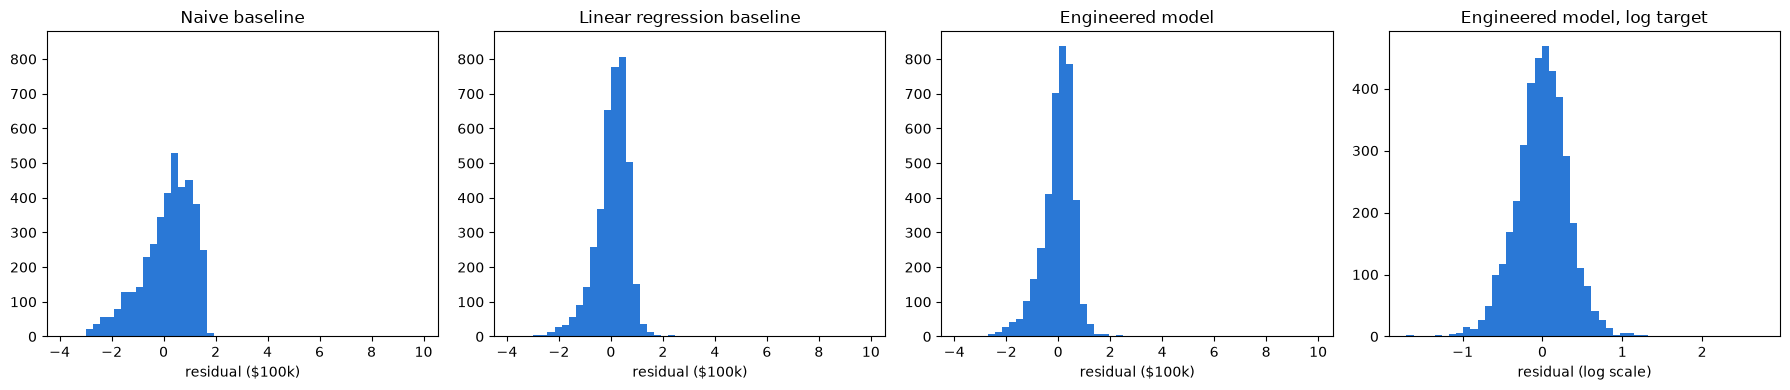

In [12]:
# fourth panel: fit on log(target) instead of raw dollars, to check whether
# log-space residuals look more symmetric than the other three
model_log = LinearRegression()
model_log.fit(X_train_eng, np.log(y_train_eng))

pred_log = model_log.predict(X_test_eng)
residuals_log = pred_log - np.log(y_test.values)

all_vals = np.concatenate([naive_residuals[~capped_mask],
                           residuals[~capped_mask],
                           residuals_eng[~capped_mask]])
shared_range_eng = (all_vals.min(), all_vals.max())

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[1].sharey(axes[0])
axes[2].sharey(axes[0])

axes[0].hist(naive_residuals[~capped_mask], bins=50, range=shared_range_eng, color="#2a78d6")
axes[0].set_title("Naive baseline")

axes[1].hist(residuals[~capped_mask], bins=50, range=shared_range_eng, color="#2a78d6")
axes[1].set_title("Linear regression baseline")

axes[2].hist(residuals_eng[~capped_mask], bins=50, range=shared_range_eng, color="#2a78d6")
axes[2].set_title("Engineered model")

axes[3].hist(residuals_log[~capped_mask], bins=50, color="#2a78d6")
axes[3].set_title("Engineered model, log target")

for i, ax in enumerate(axes):
    ax.set_xlabel("residual ($100k)" if i < 3 else "residual (log scale)")

plt.tight_layout()
plt.show()

The engineering decisions worked, and specifically on the thing they were
meant to fix. On non-capped test rows, the extreme tail shrinks sharply:
max error drops from +9.88 to +3.66, confirming the log-transform tamed the
exact leverage point that caused it. The bulk also tightens a bit (std 0.63
vs 0.66). Capped-row performance is essentially unchanged (mean -1.15 vs
-1.13 before), exactly as expected: nothing about transforming features or
changing the training set touches the fact that those labels are truncated.
That's not a failure, it's confirmation the two problems really were
independent, each fix did its own job and nothing else.

Before moving to regularization: are all 8 features actually statistically meaningful in this plain fit? p-values answer that directly, independent of feature scale.

In [13]:
import statsmodels.api as sm

# same engineered features and log target as model_log, plus a constant term, which sklearn fits implicitly but statsmodels needs explicitly
X_train_const = sm.add_constant(X_train_eng)
ols_log = sm.OLS(np.log(y_train_eng), X_train_const).fit()
print(ols_log.summary())

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.617
Model:                            OLS   Adj. R-squared:                  0.617
Method:                 Least Squares   F-statistic:                     3167.
Date:                Sat, 03 Oct 2026   Prob (F-statistic):               0.00
Time:                        12:46:59   Log-Likelihood:                -4855.3
No. Observations:               15726   AIC:                             9729.
Df Residuals:                   15717   BIC:                             9798.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -21.1734      0.355    -59.701      0.0

<a id="toc-5"></a>

## 5. Model Comparison

<a id="toc-5a"></a>

### (a) Choosing a metric

We need a metric to compare models against each other, and specifically to
score each fold during cross-validation: without one, there's no single
number to rank Ridge against Lasso against a tree.

A good metric depends partly on the residuals' distribution, which is
exactly why we wanted something reasonably symmetric to work with: fitting
in log space gives us a shape classical distributions can actually
describe.

Strictly, pinning that distribution down isn't required: with ~4,000 test
points, the central limit theorem means our chosen metric would be
estimated reliably regardless of the residuals' exact shape. But getting as
close as possible to what we actually observe gives the choice real
backing, not just convenience.

In [14]:
from scipy import stats

# fit a few standard distributions via maximum likelihood, and compare
# them with AIC (penalizes Student-t's extra degrees-of-freedom parameter);
# Cauchy included just for illustration, as the "moments don't exist" extreme
data = residuals_log[~capped_mask]
candidates = {"normal": stats.norm, "laplace": stats.laplace, "t": stats.t, "cauchy": stats.cauchy}

fits = {}
for name, dist in candidates.items():
    params = dist.fit(data)
    loglik = np.sum(dist.logpdf(data, *params))
    aic = 2 * len(params) - 2 * loglik
    fits[name] = params
    print(f"{name:8s}: log-likelihood={loglik:8.1f}   AIC={aic:8.1f}")

normal  : log-likelihood= -1295.1   AIC=  2594.2
laplace : log-likelihood= -1272.7   AIC=  2549.4
t       : log-likelihood= -1183.5   AIC=  2372.9
cauchy  : log-likelihood= -1732.7   AIC=  3469.4


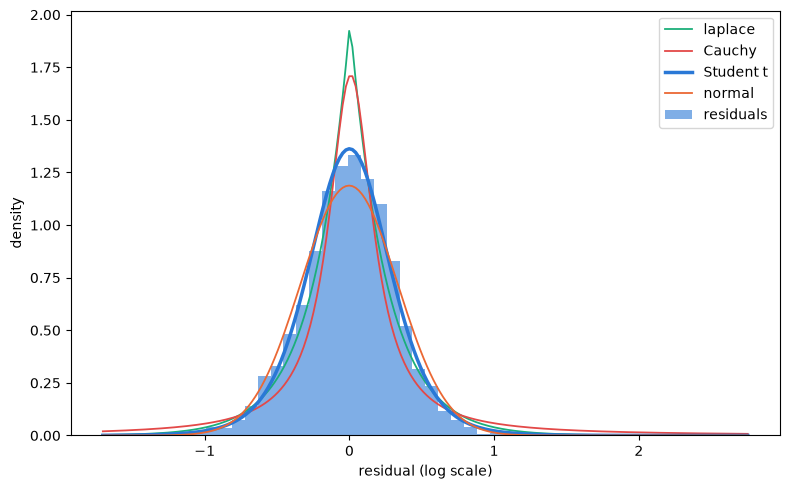

In [15]:
# overlay each fitted distribution's density on the actual residuals;
# legend ordered by peak height, Student t (the one we're choosing) in the
# same blue as the data and drawn thicker, the rest thinner
x = np.linspace(data.min(), data.max(), 200)
order  = ["laplace", "cauchy", "t", "normal"]
colors = {"laplace": "#1baf7a", "cauchy": "#e34948", "t": "#2a78d6", "normal": "#eb6834"}
labels = {"laplace": "laplace", "cauchy": "Cauchy", "t": "Student t", "normal": "normal"}
widths = {"laplace": 1.3, "cauchy": 1.3, "t": 2.5, "normal": 1.3}

fig, ax = plt.subplots(figsize=(8, 5))
_, _, hist_patches = ax.hist(data, bins=50, density=True, color="#2a78d6", alpha=0.6)

lines = []
for name in order:
    line, = ax.plot(x, candidates[name].pdf(x, *fits[name]), color=colors[name],
                     linewidth=widths[name], label=labels[name])
    lines.append(line)

ax.set_xlabel("residual (log scale)")
ax.set_ylabel("density")
ax.legend(handles=lines + [hist_patches], labels=[labels[n] for n in order] + ["residuals"])

plt.tight_layout()
plt.show()

Not Laplace: Student-t wins clearly on AIC (2373 vs. 2549 for Laplace, 2594
for Normal), and the plot confirms it, Laplace overshoots the peak and
undershoots the shoulders, Normal is too wide at the peak, t tracks the
actual shape closely. The fitted degrees of freedom is about 7: heavier
tails than Gaussian, though not the extreme case Laplace or Cauchy would
represent. That's a real, evidence-based reason to favor MAE-style
evaluation over RMSE, exactly the kind of grounding this decision should
rest on, rather than an assumption.

Why Student-t specifically, not just that it fits: it arises mathematically
as a mixture of Gaussians whose variance itself varies, which maps directly
onto this task. Predicting home value from 8 generic features is easy (low
noise) for a typical neighborhood and genuinely hard (high noise) for an
atypical one, like the tiny-household block group behind our leverage
point. A single global linear model assumes one constant noise level
everywhere, but the real difficulty varies by neighborhood; pooling
residuals across neighborhoods with different inherent unpredictability is
exactly what produces a heavier-than-Gaussian, Student-t-shaped aggregate.
That's independent, aggregate-level confirmation of something section 4(c)
already found anecdotally at the single-row level, and a preview of why a
tree-based model, which can adapt locally, might help later.

**Decision: MAE, computed in log space, as the primary metric for model
comparison and cross-validation.** This is a well-grounded choice, not a
default: we transformed the target to get well-behaved residuals, tested
several candidate distributions rather than assuming one, and found a
moderately heavy-tailed Student-t fits best. That's a solid, evidence-based
justification for MAE over RMSE. RMSE wouldn't have been an unreasonable
choice either: the central limit theorem guarantees it would still give a
reliable, trustworthy number regardless of the residuals' exact shape, even
without this distributional backing. But there's no reason to abandon the
direction this analysis has pointed us in: work in log space, and favor a
metric that doesn't let large errors dominate. RMSE will still be reported
alongside, both for a fuller picture and because it's the metric most
commonly reported elsewhere for this dataset.

<a id="toc-5b"></a>

### (b) Underfitting assessment

With the metric settled, the first thing to check with it: does the
(now-fixed) model fit even its own training data well, or has it already
hit a structural ceiling? That's underfitting, and it's checkable before
touching regularization at all, just one fitted model and two sets of
predictions.

In [16]:
# a gap (training error much lower than test) would be overfitting; both stuck at a similarly high error is underfitting
train_mae = np.abs(model_log.predict(X_train_eng) - np.log(y_train_eng)).mean()
test_mae  = np.abs(residuals_log[~capped_mask]).mean()
print(f"training MAE(log): {train_mae:.4f}")
print(f"test MAE(log):     {test_mae:.4f}")

training MAE(log): 0.2513
test MAE(log):     0.2539


Confirmed: training error (0.2513) and test error (0.2539) are essentially
identical, no gap, so the fixes applied in section 4 weren't masking an
overfitting problem. But both sit at the same, non-trivial error level:
the model can't fit even its own training data much better than it
predicts new data. That's the signature of underfitting, and specifically
a structural one, not an optimization problem, linear regression's
closed-form solution is already the exact best fit possible for this
feature set, there's no "trying harder". The model form itself may be the
ceiling, worth checking against overfitting next for the full picture.

<a id="toc-5c"></a>

### (c) Overfitting assessment

With a metric decided, we can finally start building and comparing models
instead of just diagnosing the one we have. Three regularized variants of
linear regression, Ridge, Lasso, and ElasticNet, each adding a different
penalty to the cost function, test exactly this: does penalizing large
coefficients improve held-out performance? If it does, the plain model was
overfitting. Each is fit via cross-validation to pick the penalty strength,
and scored with MAE in log space.

This is also precisely the point where feature scaling starts to matter:
the penalty acts on raw coefficient size, so unscaled features bias it
unfairly toward whichever ones happen to sit on a larger numeric scale.
Each model is wrapped in a pipeline with `StandardScaler`, fit fresh inside
every cross-validation fold, so nothing about the held-out fold leaks into
the scaling.

In [17]:
from sklearn.linear_model    import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics         import mean_absolute_error, make_scorer
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler

# LassoCV/ElasticNetCV always select alpha via MSE internally; GridSearchCV with an explicit MAE scorer keeps all three on the same metric
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# same engineered features and excluded-capped-rows training set as before, but the target is now log(price), matching the metric decision
y_train_log = np.log(y_train_eng)

# range of penalty strengths to search over, from almost none to fairly strong
alphas = np.logspace(-3, 1, 30)

# each estimator wrapped with StandardScaler in a pipeline, so alpha penalizes standardized coefficients, not raw-scale ones; ElasticNet also searches l1_ratio
param_grids = {
    "Ridge":      (Pipeline([("scale", StandardScaler()), ("model", Ridge())]),
                   {"model__alpha": alphas}),
    "Lasso":      (Pipeline([("scale", StandardScaler()), ("model", Lasso(max_iter=10000))]),
                   {"model__alpha": alphas}),
    "ElasticNet": (Pipeline([("scale", StandardScaler()), ("model", ElasticNet(max_iter=10000))]),
                   {"model__alpha": alphas, "model__l1_ratio": [0.1, 0.5, 0.7, 0.9, 0.95]}),
}

# 5-fold cross-validation per model: the pipeline re-fits StandardScaler on each training fold, fits on 4 folds, scores the 5th with MAE(log)
best_models = {}
searches    = {}
for name, (estimator, grid) in param_grids.items():
    search = GridSearchCV(estimator, grid, scoring=mae_scorer, cv=5)
    search.fit(X_train_eng, y_train_log)
    best_models[name] = search.best_estimator_
    searches[name]    = search
    print(f"{name:10s}: best params = {search.best_params_}   CV MAE(log) = {-search.best_score_:.4f}")

Ridge     : best params = {'model__alpha': np.float64(0.001)}   CV MAE(log) = 0.2514


Lasso     : best params = {'model__alpha': np.float64(0.001)}   CV MAE(log) = 0.2517


ElasticNet: best params = {'model__alpha': np.float64(0.001), 'model__l1_ratio': 0.1}   CV MAE(log) = 0.2515


In [18]:
# test-set target in the same log scale as training, so comparisons are apples-to-apples
y_test_log = np.log(y_test.values)

# compare the three CV-tuned models against the plain, unregularized linear fit from section (a), to see whether regularization actually helps here
models_to_eval = {"Linear (log target)": model_log, **best_models}

print(f"{'model':20s}  {'MAE(log)':>10s}  {'RMSE(log)':>10s}")
for name, m in models_to_eval.items():
    # non-capped rows only, same evaluation convention used throughout
    pred   = m.predict(X_test_eng)[~capped_mask]
    actual = y_test_log[~capped_mask]
    mae    = mean_absolute_error(actual, pred)
    rmse   = np.sqrt(np.mean((pred - actual) ** 2))
    print(f"{name:20s}  {mae:10.4f}  {rmse:10.4f}")

model                   MAE(log)   RMSE(log)
Linear (log target)       0.2539      0.3359
Ridge                     0.2539      0.3359
Lasso                     0.2542      0.3359
ElasticNet                0.2540      0.3359


Visually, how flat is that curve across alpha, and does Lasso actually drop any feature at its chosen (near-zero) penalty? Both checkable directly rather than inferred.

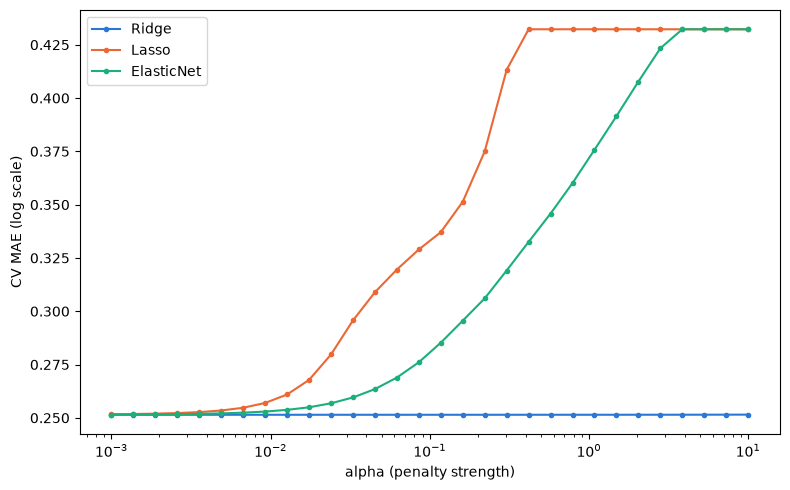

In [19]:
# validation curve: CV MAE vs alpha, one line per model (ElasticNet shown at its own best l1_ratio, to stay a comparable 1D curve)
fig, ax = plt.subplots(figsize=(8, 5))
for name, color in zip(["Ridge", "Lasso", "ElasticNet"], ["#2a78d6", "#eb6834", "#1baf7a"]):
    results = searches[name].cv_results_
    if name == "ElasticNet":
        best_l1 = searches[name].best_params_["model__l1_ratio"]
        mask = np.array(results["param_model__l1_ratio"]) == best_l1
    else:
        mask = np.ones(len(results["param_model__alpha"]), dtype=bool)
    alphas_plot = np.array(results["param_model__alpha"], dtype=float)[mask]
    scores_plot = -np.array(results["mean_test_score"])[mask]
    ax.plot(alphas_plot, scores_plot, color=color, marker="o", markersize=3, label=name)

ax.set_xscale("log")
ax.set_xlabel("alpha (penalty strength)")
ax.set_ylabel("CV MAE (log scale)")
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
# does Lasso actually drop (zero out) any feature at its chosen alpha? coefficients are now on standardized features, so sizes are genuinely comparable
lasso_coefs = pd.Series(best_models["Lasso"].named_steps["model"].coef_, index=X_train_eng.columns)
print(lasso_coefs.sort_values(key=abs, ascending=False))

Latitude     -0.520045
Longitude    -0.493675
MedInc        0.379139
AveRooms     -0.111213
AveBedrms     0.104924
HouseAge      0.040005
AveOccup     -0.019556
Population    0.011380
dtype: float64


Confirmed visually and numerically, and barely moved after fixing the
scaling: Ridge is flat across the entire alpha range, Lasso/ElasticNet
flat for small alpha then degrade once the penalty erases real signal,
same story as before, same optimal alpha (≈0.001), same CV MAE. What did
change meaningfully: Lasso's coefficients are now on a standardized scale,
genuinely comparable, and the ranking looks different, and more sensible,
than the raw version did. `Latitude` (-0.52) and `Longitude` (-0.49) are
now the two strongest predictors, ahead of even `MedInc` (0.38), consistent
with the well-known fact that location dominates California real estate
prices. `Population` (0.011), `AveOccup` (-0.020), and `HouseAge` (0.040)
remain the smallest, the same three identified before, just now on a scale
that actually means something.

Reading the plot itself: lower MAE is always better, and there are two
different flat regions here, which look the same but mean opposite things.
The flat region on the left (small alpha) is flat *and low*: the penalty
is too weak to change anything, performance stays at its best. The flat
region on the right (alpha 5-10, Lasso/ElasticNet) is flat *and high*: the
penalty has already crushed every coefficient toward zero, so increasing
it further does nothing, there's nothing left to shrink. The right choice
is the lowest point on the curve, not wherever it happens to be flat, and
here that lowest point sits at the smallest alpha tested for all three
models.

Clear answer to the bigger question: yes, this round of model-switching
didn't improve anything over the plain linear fit, and that's a real,
useful finding, not a wasted step, there was no way to know without
checking. What it actually means:

- **Use the plain (unregularized) linear model going forward**, not
  Ridge/Lasso/ElasticNet: they add a hyperparameter to tune and justify,
  for zero measurable benefit here.
- **Not "all features are equally relevant."** Lasso's own coefficients
  show `Population`, `AveOccup`, and `HouseAge` contributing almost
  nothing, just not enough to be worth dropping entirely at this alpha.
  Five features are doing essentially all the work.
- **Not "linear regression is the right model."** Only that, among linear
  models, regularization has nothing left to add. The Student-t finding
  already pointed at neighborhood-level heterogeneity a linear model can't
  represent, and shrinking coefficients doesn't change that: a global
  linear model still fits one relationship everywhere. That's precisely
  the gap a tree-based model is built to fill, which is the next step.

<a id="toc-5d"></a>

### (d) Feature importance assessment

Section 4(d) already checked this with p-values (yes, overwhelmingly). The
direct, outcome-based confirmation: does actually dropping the weakest
ones, `Population`, `AveOccup`, and `HouseAge`, change cross-validated
performance?

In [21]:
from sklearn.model_selection import cross_val_score

# same 5-fold CV and MAE(log) scorer used throughout, just on fewer columns
weak_features = ["Population", "AveOccup", "HouseAge"]
X_train_pruned = X_train_eng.drop(columns=weak_features)

full_scores   = cross_val_score(LinearRegression(), X_train_eng,    y_train_log, scoring=mae_scorer, cv=5)
pruned_scores = cross_val_score(LinearRegression(), X_train_pruned, y_train_log, scoring=mae_scorer, cv=5)

print(f"full (8 features):   CV MAE(log) = {-full_scores.mean():.4f}")
print(f"pruned (5 features): CV MAE(log) = {-pruned_scores.mean():.4f}")

full (8 features):   CV MAE(log) = 0.2514
pruned (5 features): CV MAE(log) = 0.2532


Settled, with the full reasoning, not just the number. Dropping the 3
features makes CV MAE reliably worse, not just numerically: a paired test
across the same 5 folds confirms the gap isn't noise (p=0.0006). Reliable
isn't automatically worth keeping, though, the gain is only ~0.7% relative
MAE, small enough that an Occam's-razor view could reasonably argue for the
simpler 5-feature model, trading a little predictive power for a visibly
cleaner story.

**Decision: keep all 8 features.** Some are clearly less important than
others, but the statistical tests, both the p-values and the ablation
test, show these three carry a real, non-zero contribution, not noise
dressed up as signal. Since the evidence says they're genuinely relevant,
that outweighs the appeal of a shorter list for its own sake. Coefficient
size alone was the wrong test to judge this by in the first place: it's
scale-dependent, p-values and an actual ablation test aren't.

<a id="toc-5e"></a>

### (e) Multicollinearity assessment

VIF (Variance Inflation Factor) quantifies exactly how much each
coefficient's variance is inflated by correlation with the others, the
precise tool for confirming which features are the real culprits, rather
than assuming it's `AveRooms`/`AveBedrms` just because they're both
ratios.

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF > ~5-10 is the usual rule-of-thumb threshold for concerning collinearity
vif = pd.Series([variance_inflation_factor(X_train_const.values, i) for i in range(X_train_const.shape[1])],
                 index=X_train_const.columns)
print(vif.sort_values(ascending=False))

Latitude      9.850726
Longitude     9.296512
AveRooms      3.179109
MedInc        2.582702
AveBedrms     1.956933
HouseAge      1.291905
Population    1.138616
AveOccup      1.011947
const         1.000000
dtype: float64


The hypothesis was wrong, and VIF is what catches that. `AveRooms`/`AveBedrms`
sit at 3.2 and 2.0, comfortably under the usual concern threshold, not the
problem. The real signal is `Latitude`/`Longitude`, at 9.9 and 9.3, right at
the edge of it. That makes sense once named: a 2D location in a
diagonally-shaped state like California will always carry some correlation
between its two coordinates, it's not a redundancy to engineer away, both
axes are needed to know where something actually is.

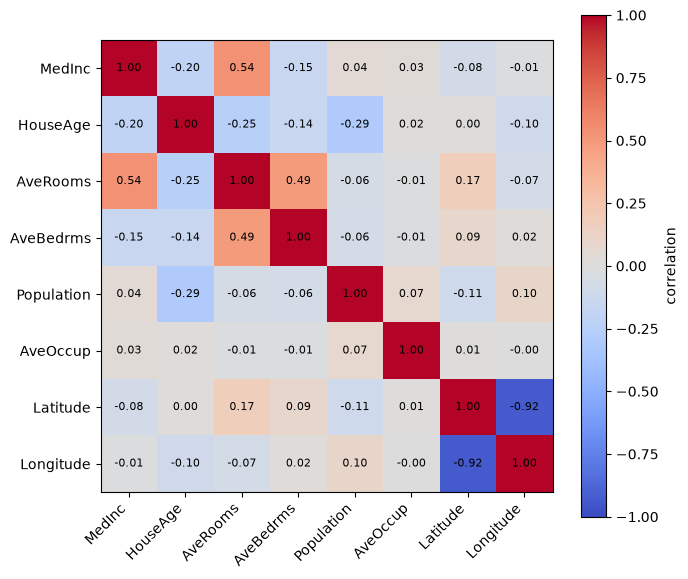

In [23]:
# correlation matrix: visual confirmation that Latitude/Longitude, not AveRooms/AveBedrms, is the standout pair
corr = X_train_eng.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, label="correlation")
plt.tight_layout()
plt.show()

One more check: the original OLS summary's "condition number is large" warning, how much of that was genuine collinearity versus just unscaled features throwing off a scale-sensitive diagnostic, the same confound that made raw coefficient size misleading earlier?

In [24]:
from sklearn.preprocessing import StandardScaler

# same features, same fit, just standardized first: isolates how much of the warning was scale, not correlation
X_train_scaled = sm.add_constant(StandardScaler().fit_transform(X_train_eng))
ols_scaled = sm.OLS(np.log(y_train_eng.values), X_train_scaled).fit()

print(f"condition number, unstandardized: {ols_log.condition_number:,.0f}")
print(f"condition number, standardized:   {ols_scaled.condition_number:,.1f}")

condition number, unstandardized: 249,315
condition number, standardized:   6.3


Mostly scale, confirmed: the condition number drops from 249,315 to 6.3,
excellent, no numerical concern at all, once features are standardized.
The original warning was overwhelmingly an artifact of features sitting on
wildly different scales (the same issue that made raw coefficient size
misleading earlier in this section), not a sign of severe collinearity.

**Conclusion.** The original plan, combining `AveRooms`/`AveBedrms` into one
ratio, was built on a wrong assumption and is dropped: VIF shows they're
not the issue (3.2 and 2.0, both comfortable). The real, and genuinely
strong, correlation is `Latitude`/`Longitude` (-0.92), which isn't a
redundancy to engineer away, a 2D location needs both coordinates, dropping
either would lose real information about where a block group actually is.
**The actual fix for trustworthy, comparable coefficients is standardizing
the features before interpreting them, not combining any of them.** That
also resolves, more rigorously, the earlier question of comparing
coefficient sizes across features on very different scales.

This should have applied to Ridge/Lasso/ElasticNet in section (c) from the
start, not just noted here: scaling matters precisely where a penalty acts
on raw coefficient size, which is exactly what regularization does. That's
now fixed at the source (section (c) refits each model inside a
`StandardScaler` pipeline) rather than patched after the fact.

<a id="toc-6"></a>

## 6. Beyond Linear Models

<a id="toc-6a"></a>

### (a) Why a decision tree

Section 5 closed with a model that isn't overfitting (regularization
barely moved the needle) but is genuinely underfitting (training and test
error sit at the same elevated level, ~0.25 in log space). That's not a
tuning problem: OLS already found linear regression's exact optimum in
closed form, so there's nothing left to extract by adjusting it further.
The ceiling is the model's shape.

Section 5(a)'s own distribution-fitting exercise pointed at why: residuals
are Student-t shaped, heavier-tailed than Gaussian, which arises as a
mixture of Gaussians with varying variance. In plain terms, some
neighborhoods are intrinsically easier to price than others, and a single
global linear equation applies the same relationship everywhere,
structurally unable to represent that. A decision tree can: instead of one
equation, it splits the data into regions and fits each on its own terms.

That's the actual justification for trying a tree specifically, not "we
ran out of ideas, try something else." No statistical result pointed at
polynomial terms or a particular kernel; this one does point at
region-dependent behavior, which is exactly what a tree is built to
capture.

<a id="toc-6b"></a>

### (b) Fitting and tuning

Unconstrained, a tree can grow until it has perfectly memorized the
training set, pure overfitting. `max_depth` controls that, so it needs the
same cross-validated search `alpha` got for Ridge/Lasso, scored with the
same MAE-in-log-space metric used throughout. Trees split on relative
order, not raw magnitude, so no feature scaling is needed here.

In [25]:
from sklearn.tree import DecisionTreeRegressor

# unconstrained trees overfit by construction, so max_depth is tuned the same way alpha was for Ridge/Lasso
depths = range(2, 21)
tree_search = GridSearchCV(DecisionTreeRegressor(random_state=42), {"max_depth": depths}, scoring=mae_scorer, cv=5)
tree_search.fit(X_train_eng, y_train_log)
best_tree = tree_search.best_estimator_
print(f"best max_depth = {tree_search.best_params_['max_depth']}   CV MAE(log) = {-tree_search.best_score_:.4f}")

best max_depth = 10   CV MAE(log) = 0.2061


Same visual check used for alpha: does CV error trace a U-shape across
depth, underfitting too shallow and overfitting too deep, with the chosen
depth sitting at the bottom?

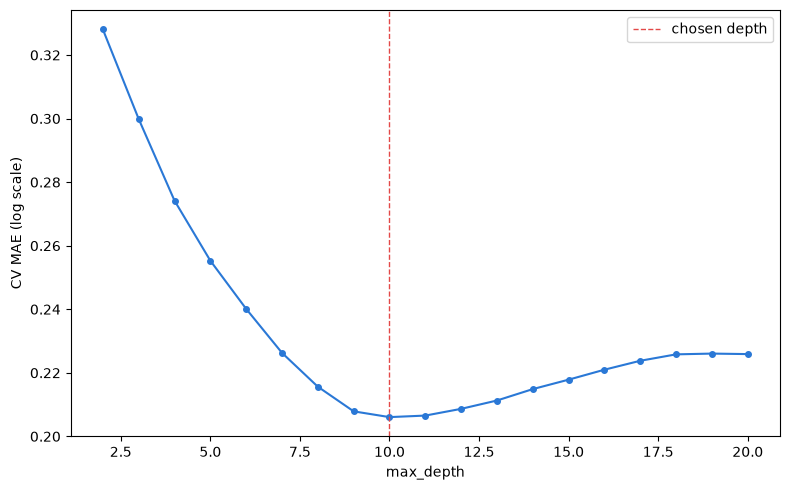

In [26]:
# same validation-curve style as the alpha plot in section 5(c), now across tree depth
results     = tree_search.cv_results_
depths_plot = np.array(results["param_max_depth"], dtype=int)
scores_plot = -np.array(results["mean_test_score"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depths_plot, scores_plot, color="#2a78d6", marker="o", markersize=4)
ax.axvline(tree_search.best_params_["max_depth"], color="#e34948", linestyle="--", linewidth=1, label="chosen depth")
ax.set_xlabel("max_depth")
ax.set_ylabel("CV MAE (log scale)")
ax.legend()
plt.tight_layout()
plt.show()

A textbook U-shape: CV error falls steadily from depth 2 (0.328) down to
depth 10 (0.206), the chosen minimum, then climbs back up through depth 20
(0.226). Both failure modes show up on the same curve: too shallow and the
tree can't represent enough structure to fit even the training data well
(underfitting), too deep and it starts memorizing individual training
points rather than generalizing (overfitting). A sharp contrast with the
alpha curve in section 5(c), which stayed essentially flat everywhere:
depth is a parameter that genuinely matters here.

<a id="toc-6c"></a>

### (c) Comparing to the linear baseline

In [27]:
# same held-out comparison convention as section 5(c): non-capped rows only, log-scale MAE and RMSE
pred_tree = best_tree.predict(X_test_eng)[~capped_mask]
actual    = y_test_log[~capped_mask]

print(f"{'model':20s}  {'MAE(log)':>10s}  {'RMSE(log)':>10s}")
for name, m in models_to_eval.items():
    pred = m.predict(X_test_eng)[~capped_mask]
    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(np.mean((pred - actual) ** 2))
    print(f"{name:20s}  {mae:10.4f}  {rmse:10.4f}")

mae_tree  = mean_absolute_error(actual, pred_tree)
rmse_tree = np.sqrt(np.mean((pred_tree - actual) ** 2))
print(f"{'Decision Tree':20s}  {mae_tree:10.4f}  {rmse_tree:10.4f}")

model                   MAE(log)   RMSE(log)
Linear (log target)       0.2539      0.3359
Ridge                     0.2539      0.3359
Lasso                     0.2542      0.3359
ElasticNet                0.2540      0.3359
Decision Tree             0.1991      0.2836


A real improvement, not a marginal one. CV MAE drops from 0.2514 (the best
linear/regularized model) to 0.2061, about 18% relative, and the held-out
test set confirms it: MAE 0.1991 vs 0.2539 (~22% relative), RMSE 0.2836 vs
0.3359. This is the exact outcome the underfitting diagnosis in section
5(b) predicted: letting the model vary its behavior by region, rather than
forcing one global linear relationship onto all of California, closes a
real part of the gap linear regression structurally couldn't.

<a id="toc-6d"></a>

### (d) Reducing variance with ensembles

A single tree is still a high-variance model: it reflects one particular
set of splits, sensitive to exactly which training rows it happened to
see. Averaging many trees (**Random Forest**) or fitting many shallow
trees sequentially, each correcting the previous ensemble's errors
(**Gradient Boosting**), are the standard fixes, a direct continuation of
the idea that made a tree help in the first place, not a new, unrelated
model family.

In [28]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# random forest: many deep trees, each seeing a random feature subset; averaging controls variance, so max_depth matters far less than it did for a single tree
rf_grid   = {"n_estimators": [200], "max_depth": [10, 20, None], "max_features": [0.5, 0.75, 1.0]}
rf_search = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), rf_grid, scoring=mae_scorer, cv=5, n_jobs=-1)
rf_search.fit(X_train_eng, y_train_log)
print(f"Random Forest    : best params = {rf_search.best_params_}   CV MAE(log) = {-rf_search.best_score_:.4f}")

# gradient boosting: many shallow trees fit sequentially, each correcting the previous ensemble's errors; depth, learning rate, and stage count all interact
gb_grid   = {"n_estimators": [100, 200], "max_depth": [2, 3, 4], "learning_rate": [0.05, 0.1]}
gb_search = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_grid, scoring=mae_scorer, cv=5, n_jobs=-1)
gb_search.fit(X_train_eng, y_train_log)
print(f"Gradient Boosting: best params = {gb_search.best_params_}   CV MAE(log) = {-gb_search.best_score_:.4f}")

Random Forest    : best params = {'max_depth': None, 'max_features': 0.75, 'n_estimators': 200}   CV MAE(log) = 0.1588


Gradient Boosting: best params = {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}   CV MAE(log) = 0.1628


In [29]:
# full comparison across every model built in this notebook, same held-out convention throughout
all_models = {**models_to_eval, "Decision Tree": best_tree,
              "Random Forest": rf_search.best_estimator_, "Gradient Boosting": gb_search.best_estimator_}

print(f"{'model':20s}  {'MAE(log)':>10s}  {'RMSE(log)':>10s}")
for name, m in all_models.items():
    pred = m.predict(X_test_eng)[~capped_mask]
    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(np.mean((pred - actual) ** 2))
    print(f"{name:20s}  {mae:10.4f}  {rmse:10.4f}")

model                   MAE(log)   RMSE(log)
Linear (log target)       0.2539      0.3359
Ridge                     0.2539      0.3359
Lasso                     0.2542      0.3359
ElasticNet                0.2540      0.3359
Decision Tree             0.1991      0.2836
Random Forest             0.1556      0.2249
Gradient Boosting         0.1620      0.2309


Both ensembles beat the single tree, confirming the variance diagnosis: CV
MAE improves from 0.2061 (tree) to 0.1588 (Random Forest) and 0.1628
(Gradient Boosting), and the held-out test set agrees (Random Forest 0.1556,
Gradient Boosting 0.1620, vs the tree's 0.1991). Random Forest edges out
Gradient Boosting here, and notably picked an unconstrained `max_depth`:
unlike a single tree, letting each tree grow fully isn't a problem once
their errors are being averaged away, variance reduction is coming from
the ensemble itself, not from constraining any individual tree.

**Random Forest is the best model built in this notebook**: MAE 0.1556 in
log space, a 39% relative improvement over the best linear model (0.2539)
and a 66% improvement over the naive baseline.

<a id="toc-7"></a>

## 7. Conclusion

<a id="toc-7a"></a>

### (a) Summary

Starting from a naive mean-prediction floor, this notebook built up to a
tuned **Random Forest**, a 66% reduction in MAE over that floor and a 39%
reduction over the best linear/regularized model tried. Every step in
between was driven by evidence read off the previous model's errors, not
by trying techniques in sequence for their own sake:

| step | finding | action |
|---|---|---|
| Baseline errors | Heavy tail, far worse than the naive floor's | Investigated instead of accepted |
| Error analysis | Target censored at its max; one feature pair (`AveRooms`/`AveBedrms`) producing extreme leverage points | Excluded capped rows from training; log-transformed the two ratio features |
| Metric choice | Residuals fit a Student-t distribution best, heavier-tailed than Gaussian | MAE in log space, not RMSE in raw dollars |
| Overfitting check | Ridge/Lasso/ElasticNet matched the plain fit almost exactly | Regularization added nothing; plain linear regression kept |
| Feature importance | All 8 features statistically significant; dropping the 3 weakest reliably hurt CV error | Kept all 8, with the reasoning made explicit rather than judged by coefficient size |
| Multicollinearity | VIF pointed at `Latitude`/`Longitude`, not the assumed `AveRooms`/`AveBedrms` pair | No feature combined; coefficients interpreted on standardized scale instead |
| Underfitting check | Training and test error nearly identical, both high | Linear regression had hit a structural ceiling, not a tuning one |
| Decision tree | Fixed a real chunk of that ceiling (MAE 0.2539 → 0.1991) | Confirmed the ceiling was the model's shape, not its parameters |
| Ensembles | Averaging many trees reduced variance further (MAE → 0.1556) | Random Forest selected as the final model |

<a id="toc-7b"></a>

### (b) What worked, and why

- **Diagnose before deciding.** Every fix in this notebook followed from an
  error analysis, not an assumption: the leverage point, the metric
  choice, and especially the multicollinearity culprit, where the first
  guess (`AveRooms`/`AveBedrms`) was wrong and VIF caught it. Trusting a
  plausible-looking hypothesis over actually checking it would have fixed
  the wrong thing.
- **Statistical and practical significance are different questions.**
  p-values told us all 8 features carry real signal; the ablation test's
  effect size (a 0.7% relative gain) told us whether that signal was worth
  the added complexity. Coefficient magnitude alone, before standardizing,
  answered neither question correctly.
- **Scale matters anywhere magnitude is compared or penalized.** Raw
  coefficients, the condition-number warning, and the Ridge/Lasso/
  ElasticNet penalty all looked more alarming, or more informative, than
  they actually were until features were standardized first.
- **Underfitting and overfitting are different diagnoses, with different
  fixes.** Regularization, the overfitting fix, could never have closed
  the underfitting gap found in section 5(b); only a model with more
  capacity for this feature set could. Checking both, rather than
  assuming one from the other, is what pointed at trees specifically.
- **A model-family change needs its own evidence**, not "try the next
  thing on the list." The Student-t residual shape (section 5(a)) gave a
  specific, falsifiable reason to expect region-dependent behavior, which
  is exactly what a tree, not a polynomial term or a different linear
  penalty, is built to capture.
- **A single tree is not the end of that idea.** Its own high variance
  pointed directly at ensembling (averaging many trees) as the next,
  well-justified step, not a new model family.

<a id="toc-7c"></a>

### (c) Why we stop here

Two techniques were deliberately not tried, each for a specific reason,
not lack of time:

- **Polynomial/interaction linear regression.** Legitimate in principle,
  but it requires guessing which interactions matter (`Latitude ×
  MedInc`? `Latitude × Longitude`?) with no statistical result here
  pointing at specific terms. A tree already finds that structure
  automatically, reaching the same goal with less manual guesswork and no
  risk of missing the interaction that actually matters.
- **Neural networks.** Two independent reasons, not one. This dataset is
  small and tabular (≈16k rows, 8 generic features), exactly the regime
  where tree ensembles typically match or beat neural networks; there's no
  unstructured, high-dimensional input (images, text) where a network's
  representation learning would pay for its own complexity. And nothing in
  this notebook's diagnosis calls for one specifically, unlike the tree,
  which the Student-t finding motivated directly. Trying one here would be
  exactly the kind of untargeted "test it and see" this notebook set out
  to avoid. A neural network deserves its own exercise, with data and a
  problem where the choice can be justified the same way every other step
  here was, not retrofitted onto a dataset that doesn't need it.

<a id="toc-7d"></a>

### (d) Possible extensions

If this model needed to go further: a broader hyperparameter search for
the Random Forest and Gradient Boosting (the grids here were deliberately
modest), engineered location features if finer-grained geographic data
became available (county, zip, distance to the coast), and a dedicated
neural-network exercise elsewhere in this repo, once a dataset exists
where that choice is actually motivated rather than assumed.